In [3]:
# Cell 1: Import Libraries and Set Parameters
import os
import pandas as pd
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, GRU, LSTM, Input, concatenate, Reshape, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

SAMPLE_RATE = 16000
DURATION = 10
N_MFCC = 20
N_MELS = 64
HOP_LENGTH = 256
N_FFT = 1024
WINDOW_SIZE = 4
OVERLAP_RATIO = 0.5

EPOCHS = 100
BATCH_SIZE = 128
LEARNING_RATE = 0.0005
WEIGHT_DECAY = 1e-4

DATA_DIR = r"c:\Users\VICTUS\OneDrive\Desktop\respiratory_disease_classification\data\Respiratory_Sound_Database"
DIAGNOSIS_FILE = os.path.join(DATA_DIR, "patient_diagnosis.csv")
AUDIO_DIR = os.path.join(DATA_DIR, "audio_and_txt_files")

print("Libraries imported and parameters set successfully!")

Libraries imported and parameters set successfully!


In [4]:

# Cell 2: Load Diagnosis Data and Audio Files
diagnosis_df = pd.read_csv(DIAGNOSIS_FILE)
print(f"Diagnosis data shape: {diagnosis_df.shape}")
print(f"Columns: {diagnosis_df.columns.tolist()}")
print("\nFirst few rows:")
print(diagnosis_df.head())

audio_files = [f for f in os.listdir(AUDIO_DIR) if f.endswith('.wav')]
print(f"\nTotal audio files found: {len(audio_files)}")
print(f"Sample audio files: {audio_files[:5]}")

print(f"\nDiagnosis distribution:")
print(diagnosis_df.iloc[:, 1].value_counts())

Diagnosis data shape: (125, 2)
Columns: ['101', 'URTI']

First few rows:
   101     URTI
0  102  Healthy
1  103   Asthma
2  104     COPD
3  105     URTI
4  106     COPD

Total audio files found: 920
Sample audio files: ['101_1b1_Al_sc_Meditron.wav', '101_1b1_Pr_sc_Meditron.wav', '102_1b1_Ar_sc_Meditron.wav', '103_2b2_Ar_mc_LittC2SE.wav', '104_1b1_Al_sc_Litt3200.wav']

Diagnosis distribution:
URTI
COPD              64
Healthy           26
URTI              13
Bronchiectasis     7
Pneumonia          6
Bronchiolitis      6
LRTI               2
Asthma             1
Name: count, dtype: int64


In [5]:
# Cell 3: Map Patient IDs to Audio Files and Labels
def extract_patient_id(filename):
    return int(filename.split('_')[0])

audio_patient_mapping = []
for audio_file in audio_files:
    try:
        patient_id = extract_patient_id(audio_file)
        audio_patient_mapping.append({
            'filename': audio_file,
            'patient_id': patient_id,
            'filepath': os.path.join(AUDIO_DIR, audio_file)
        })
    except:
        continue

audio_df = pd.DataFrame(audio_patient_mapping)
print(f"Successfully mapped {len(audio_df)} audio files to patient IDs")

merged_df = audio_df.merge(diagnosis_df, left_on='patient_id', right_on=diagnosis_df.columns[0], how='inner')
print(f"Merged dataset shape: {merged_df.shape}")
print(f"Labels column: {merged_df.columns[-1]}")

Successfully mapped 920 audio files to patient IDs
Merged dataset shape: (918, 5)
Labels column: URTI


In [6]:
# Cell 4: Filter Classes with >= 20 Samples
label_column = merged_df.columns[-1]
class_counts = merged_df[label_column].value_counts()
print("Class distribution before filtering:")
print(class_counts)

viable_classes = class_counts[class_counts >= 20].index.tolist()
filtered_df = merged_df[merged_df[label_column].isin(viable_classes)]

print(f"\nViable classes (>= 20 samples): {viable_classes}")
print(f"Filtered dataset shape: {filtered_df.shape}")
print("\nClass distribution after filtering:")
print(filtered_df[label_column].value_counts())

Class distribution before filtering:
URTI
COPD              793
Pneumonia          37
Healthy            35
URTI               21
Bronchiectasis     16
Bronchiolitis      13
LRTI                2
Asthma              1
Name: count, dtype: int64

Viable classes (>= 20 samples): ['COPD', 'Pneumonia', 'Healthy', 'URTI']
Filtered dataset shape: (886, 5)

Class distribution after filtering:
URTI
COPD         793
Pneumonia     37
Healthy       35
URTI          21
Name: count, dtype: int64


In [7]:
# Cell 5: Audio Loading and Feature Extraction Functions
def load_audio(filepath, duration=DURATION, sr=SAMPLE_RATE):
    try:
        audio, _ = librosa.load(filepath, sr=sr, duration=duration)
        if len(audio) < sr * duration:
            audio = np.pad(audio, (0, sr * duration - len(audio)), 'constant')
        return audio
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def extract_mfcc(audio, sr=SAMPLE_RATE, n_mfcc=N_MFCC):
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc, hop_length=HOP_LENGTH, n_fft=N_FFT)
    return mfcc.T

def extract_mel_spectrogram(audio, sr=SAMPLE_RATE, n_mels=N_MELS):
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels, hop_length=HOP_LENGTH, n_fft=N_FFT)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    return mel_spec_db.T

def extract_features(audio, sr=SAMPLE_RATE):
    mfcc = extract_mfcc(audio, sr)
    mel_spec = extract_mel_spectrogram(audio, sr)
    features = np.concatenate([mfcc, mel_spec], axis=1)
    return features

print("Feature extraction functions defined successfully!")

Feature extraction functions defined successfully!


In [8]:
# Cell 6: Data Augmentation Functions
def add_noise(audio, noise_factor=0.005):
    noise = np.random.randn(len(audio))
    return audio + noise_factor * noise

def time_shift(audio, shift_max=0.2):
    shift = np.random.randint(-int(shift_max * len(audio)), int(shift_max * len(audio)))
    return np.roll(audio, shift)

def pitch_shift(audio, sr=SAMPLE_RATE, n_steps=2):
    return librosa.effects.pitch_shift(audio, sr=sr, n_steps=n_steps)

def time_stretch(audio, rate=1.2):
    return librosa.effects.time_stretch(audio, rate=rate)

def augment_audio(audio, sr=SAMPLE_RATE):
    augmented_audios = []
    
    augmented_audios.append(add_noise(audio))
    augmented_audios.append(time_shift(audio))
    
    try:
        augmented_audios.append(pitch_shift(audio, sr, n_steps=2))
        augmented_audios.append(pitch_shift(audio, sr, n_steps=-2))
        augmented_audios.append(time_stretch(audio, rate=1.1))
        augmented_audios.append(time_stretch(audio, rate=0.9))
    except:
        pass
    
    return augmented_audios

print("Data augmentation functions defined successfully!")

Data augmentation functions defined successfully!


In [9]:
# Cell 7: Load Audio Data and Extract Features with fixed shape
X = []
y = []

desired_shape = (216, 40)  # (time steps, features)

def extract_fixed_features(audio, sr=22050, max_len=216):
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    if mfccs.shape[1] < max_len:
        pad_width = max_len - mfccs.shape[1]
        mfccs = np.pad(mfccs, ((0, 0), (0, pad_width)), mode='constant')
    else:
        mfccs = mfccs[:, :max_len]
    return mfccs.T  # shape: (216, 40)

print("Loading audio files and extracting features...")

for idx, row in filtered_df.iterrows():
    audio = load_audio(row['filepath'])
    if audio is not None:
        features = extract_fixed_features(audio)
        X.append(features)
        y.append(row[label_column])

        augmented_audios = augment_audio(audio)
        for aug_audio in augmented_audios:
            try:
                aug_features = extract_fixed_features(aug_audio)
                X.append(aug_features)
                y.append(row[label_column])
            except:
                continue

    if idx % 50 == 0:
        print(f"Processed {idx}/{len(filtered_df)} files...")

X = np.array(X)
y = np.array(y)

print(f"Feature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Total samples after augmentation: {len(X)}")


Loading audio files and extracting features...
Processed 0/886 files...
Processed 50/886 files...
Processed 100/886 files...
Processed 150/886 files...
Processed 200/886 files...
Processed 250/886 files...
Processed 300/886 files...
Processed 350/886 files...
Processed 400/886 files...
Processed 450/886 files...
Processed 500/886 files...
Processed 550/886 files...
Processed 600/886 files...
Processed 650/886 files...
Processed 700/886 files...
Processed 750/886 files...
Processed 800/886 files...
Processed 850/886 files...
Processed 900/886 files...
Feature matrix shape: (6202, 216, 40)
Labels shape: (6202,)
Total samples after augmentation: 6202


In [10]:
# Cell 8: Encode Labels and Split Data
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
n_classes = len(label_encoder.classes_)

print(f"Number of classes: {n_classes}")
print(f"Classes: {label_encoder.classes_}")

X_temp, X_test, y_temp, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

y_train_cat = to_categorical(y_train, n_classes)
y_val_cat = to_categorical(y_val, n_classes)
y_test_cat = to_categorical(y_test, n_classes)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

Number of classes: 4
Classes: ['COPD' 'Healthy' 'Pneumonia' 'URTI']
Training set shape: (3720, 216, 40)
Validation set shape: (1241, 216, 40)
Test set shape: (1241, 216, 40)


In [11]:
import librosa

try:
    y, sr = librosa.load("101_1b1_Al_sc_Meditron.wav", sr=16000, mono=True)
    print(f"Audio loaded: shape={y.shape}, sr={sr}")
    mfcc = librosa.feature.mfcc(y=y, sr=sr)
    print(f"MFCC shape: {mfcc.shape}")
except Exception as e:
    print("Error during feature extraction:", e)


Error during feature extraction: [Errno 2] No such file or directory: '101_1b1_Al_sc_Meditron.wav'


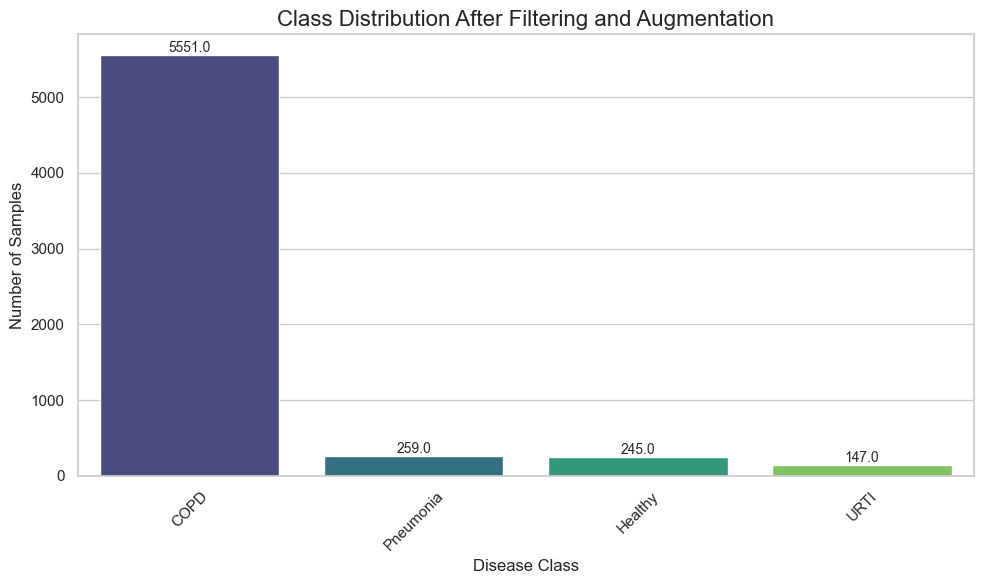

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Visualize class distribution after filtering and augmentation
label_df = pd.DataFrame({'label': y})

plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")
ax = sns.countplot(data=label_df, x='label', order=label_df['label'].value_counts().index, palette='viridis')

# Annotate bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.title("Class Distribution After Filtering and Augmentation", fontsize=16)
plt.xlabel("Disease Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()

# Save image
plt.savefig("class_distribution_after_augmentation.png", dpi=300)
plt.show()


In [10]:
# Cell 9: Define CNN Model
def create_cnn_model(input_shape, n_classes):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        
        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        
        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(n_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

input_shape = (X_train.shape[1], X_train.shape[2], 1)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_val_cnn = X_val.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

cnn_model = create_cnn_model(input_shape, n_classes)
print("CNN Model Architecture:")
cnn_model.summary()

CNN Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 214, 38, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 214, 38, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 107, 19, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 105, 17, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 105, 17, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 52, 8, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 6, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 6, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 3, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,457,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,584,836 (9.86 MB)

 Trainable params: 2,584,388 (9.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
# Cell 10: Define GRU Model
def create_gru_model(input_shape, n_classes):
    model = Sequential([
        GRU(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.3),
        GRU(64, return_sequences=False),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(n_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

gru_input_shape = (X_train.shape[1], X_train.shape[2])
gru_model = create_gru_model(gru_input_shape, n_classes)
print("GRU Model Architecture:")
gru_model.summary()


GRU Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 216, 128)       │        65,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 216, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,364 (466.27 KB)

 Trainable params: 119,364 (466.27 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Cell 11: Define CNN-GRU Hybrid Model
def create_cnn_gru_hybrid(input_shape, n_classes):
    input_layer = Input(shape=input_shape)
    
    conv1 = Conv2D(32, (3, 3), activation='relu')(input_layer)
    conv1 = BatchNormalization()(conv1)
    pool1 = MaxPooling2D((2, 2))(conv1)
    
    conv2 = Conv2D(64, (3, 3), activation='relu')(pool1)
    conv2 = BatchNormalization()(conv2)
    pool2 = MaxPooling2D((2, 2))(conv2)
    
    conv_shape = pool2.shape
    reshaped = Reshape((conv_shape[1], conv_shape[2] * conv_shape[3]))(pool2)
    
    gru1 = GRU(128, return_sequences=True)(reshaped)
    gru1 = Dropout(0.3)(gru1)
    gru2 = GRU(64, return_sequences=False)(gru1)
    gru2 = Dropout(0.3)(gru2)
    
    dense1 = Dense(256, activation='relu')(gru2)
    dense1 = Dropout(0.5)(dense1)
    dense2 = Dense(128, activation='relu')(dense1)
    dense2 = Dropout(0.3)(dense2)
    
    output = Dense(n_classes, activation='softmax')(dense2)
    
    model = Model(inputs=input_layer, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

hybrid_model = create_cnn_gru_hybrid(input_shape, n_classes)
print("CNN-GRU Hybrid Model Architecture:")
hybrid_model.summary()


CNN-GRU Hybrid Model Architecture:


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 216, 40, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 214, 38, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 214, 38, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 107, 19, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 105, 17, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 105, 17, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 52, 8, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 52, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 52, 128)        │       246,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 52, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353,028 (1.35 MB)

 Trainable params: 352,836 (1.35 MB)

 Non-trainable params: 192 (768.00 B)

In [13]:
# Cell 12: Training Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

def get_model_checkpoint(model_name):
    return ModelCheckpoint(
        f'best_{model_name}_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )

print("Training callbacks defined successfully!")

Training callbacks defined successfully!


In [14]:
# Cell 13: Train CNN Model
print("Training CNN Model...")
cnn_checkpoint = get_model_checkpoint('cnn')

cnn_history = cnn_model.fit(
    X_train_cnn, y_train_cat,
    validation_data=(X_val_cnn, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping, cnn_checkpoint],
    verbose=1
)

print("CNN Model training completed!")

Training CNN Model...
Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - accuracy: 0.7593 - loss: 1.3921
Epoch 1: val_accuracy improved from -inf to 0.89525, saving model to best_cnn_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 28s 818ms/step - accuracy: 0.7613 - loss: 1.3774 - val_accuracy: 0.8952 - val_loss: 0.4182
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 785ms/step - accuracy: 0.8675 - loss: 0.4594
Epoch 2: val_accuracy did not improve from 0.89525
30/30 ━━━━━━━━━━━━━━━━━━━━ 25s 828ms/step - accuracy: 0.8679 - loss: 0.4571 - val_accuracy: 0.7317 - val_loss: 0.7926
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 920ms/step - accuracy: 0.8975 - loss: 0.2885
Epoch 3: val_accuracy did not improve from 0.89525
30/30 ━━━━━━━━━━━━━━━━━━━━ 29s 973ms/step - accuracy: 0.8975 - loss: 0.2882 - val_accuracy: 0.7792 - val_loss: 0.6338
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8992 - loss: 0.2692
Epoch 4: val_accuracy did not improve from 0.89525
30/30 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.8993 - loss: 0.2683 - val_accuracy: 0.6793 - val_loss: 0.7672
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9123 - loss: 0.2276
Epoch 5: val_accuracy did not improv

30/30 ━━━━━━━━━━━━━━━━━━━━ 29s 952ms/step - accuracy: 0.9339 - loss: 0.1498 - val_accuracy: 0.9073 - val_loss: 0.2477
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 945ms/step - accuracy: 0.9411 - loss: 0.1386
Epoch 9: val_accuracy improved from 0.90733 to 0.91136, saving model to best_cnn_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9412 - loss: 0.1385 - val_accuracy: 0.9114 - val_loss: 0.2141
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 902ms/step - accuracy: 0.9551 - loss: 0.1128
Epoch 10: val_accuracy improved from 0.91136 to 0.94037, saving model to best_cnn_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 29s 953ms/step - accuracy: 0.9551 - loss: 0.1131 - val_accuracy: 0.9404 - val_loss: 0.1525
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 889ms/step - accuracy: 0.9575 - loss: 0.1065
Epoch 11: val_accuracy improved from 0.94037 to 0.95649, saving model to best_cnn_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 28s 941ms/step - accuracy: 0.9574 - loss: 0.1067 - val_accuracy: 0.9565 - val_loss: 0.1160
Epoch 12/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 849ms/step - accuracy: 0.9527 - loss: 0.1285
Epoch 12: val_accuracy did not improve from 0.95649
30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 896ms/step - accuracy: 0.9529 - loss: 0.1279 - val_accuracy: 0.9541 - val_loss: 0.1343
Epoch 13/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 859ms/step - accuracy: 0.9603 - loss: 0.1157
Epoch 13: val_accuracy improved from 0.95649 to 0.95810, saving model to best_cnn_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 909ms/step - accuracy: 0.9604 - loss: 0.1153 - val_accuracy: 0.9581 - val_loss: 0.1235
Epoch 14/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 839ms/step - accuracy: 0.9494 - loss: 0.1423
Epoch 14: val_accuracy did not improve from 0.95810
30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 886ms/step - accuracy: 0.9494 - loss: 0.1425 - val_accuracy: 0.9452 - val_loss: 0.1522
Epoch 15/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 847ms/step - accuracy: 0.9477 - loss: 0.1441
Epoch 15: val_accuracy improved from 0.95810 to 0.96052, saving model to best_cnn_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 900ms/step - accuracy: 0.9480 - loss: 0.1434 - val_accuracy: 0.9605 - val_loss: 0.1238
Epoch 16/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 837ms/step - accuracy: 0.9697 - loss: 0.0863
Epoch 16: val_accuracy improved from 0.96052 to 0.97421, saving model to best_cnn_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 887ms/step - accuracy: 0.9696 - loss: 0.0863 - val_accuracy: 0.9742 - val_loss: 0.0817
Epoch 17/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 844ms/step - accuracy: 0.9715 - loss: 0.0750
Epoch 17: val_accuracy did not improve from 0.97421
30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 898ms/step - accuracy: 0.9715 - loss: 0.0749 - val_accuracy: 0.9621 - val_loss: 0.0995
Epoch 18/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 841ms/step - accuracy: 0.9820 - loss: 0.0498
Epoch 18: val_accuracy did not improve from 0.97421
30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 894ms/step - accuracy: 0.9820 - loss: 0.0498 - val_accuracy: 0.9710 - val_loss: 0.0847
Epoch 19/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 831ms/step - accuracy: 0.9523 - loss: 0.1317
Epoch 19: val_accuracy did not improve from 0.97421
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 878ms/step - accuracy: 0.9526 - loss: 0.1310 - val_accuracy: 0.9500 - val_loss: 0.1618
Epoch 20/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 848ms/step - accuracy: 0.9749 - loss: 0.0645
Epoch 20: val_accura

30/30 ━━━━━━━━━━━━━━━━━━━━ 29s 951ms/step - accuracy: 0.9883 - loss: 0.0297 - val_accuracy: 0.9799 - val_loss: 0.0681
Epoch 24/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9881 - loss: 0.0306
Epoch 24: val_accuracy did not improve from 0.97985
30/30 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.9881 - loss: 0.0306 - val_accuracy: 0.9517 - val_loss: 0.1781
Epoch 25/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9919 - loss: 0.0254
Epoch 25: val_accuracy did not improve from 0.97985
30/30 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.9919 - loss: 0.0255 - val_accuracy: 0.9654 - val_loss: 0.1036
Epoch 26/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9931 - loss: 0.0211
Epoch 26: val_accuracy did not improve from 0.97985
30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.9931 - loss: 0.0211 - val_accuracy: 0.9726 - val_loss: 0.0847
Epoch 27/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9938 - loss: 0.0195
Epoch 27: val_accuracy did not improve fr

In [15]:
# Cell 14: Train GRU Model
print("Training GRU Model...")
gru_checkpoint = get_model_checkpoint('gru')

gru_history = gru_model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping, gru_checkpoint],
    verbose=1
)

print("GRU Model training completed!")


Training GRU Model...
Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.5620 - loss: 1.0677
Epoch 1: val_accuracy improved from -inf to 0.89525, saving model to best_gru_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 458ms/step - accuracy: 0.5684 - loss: 1.0574 - val_accuracy: 0.8952 - val_loss: 0.4459
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.8962 - loss: 0.4437
Epoch 2: val_accuracy did not improve from 0.89525
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 381ms/step - accuracy: 0.8961 - loss: 0.4435 - val_accuracy: 0.8952 - val_loss: 0.3470
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.8960 - loss: 0.3842
Epoch 3: val_accuracy did not improve from 0.89525
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 465ms/step - accuracy: 0.8960 - loss: 0.3839 - val_accuracy: 0.8952 - val_loss: 0.3223
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.8996 - loss: 0.3388
Epoch 4: val_accuracy did not improve from 0.89525
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 365ms/step - accuracy: 0.8994 - loss: 0.3387 - val_accuracy: 0.8952 - val_loss: 0.2920
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.8973 - loss: 0.3109
Epoch 5: val_accuracy did n

30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 354ms/step - accuracy: 0.8952 - loss: 0.2521 - val_accuracy: 0.8985 - val_loss: 0.2263
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.9046 - loss: 0.2193
Epoch 8: val_accuracy improved from 0.89847 to 0.91136, saving model to best_gru_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 365ms/step - accuracy: 0.9045 - loss: 0.2198 - val_accuracy: 0.9114 - val_loss: 0.2136
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.9030 - loss: 0.2197
Epoch 9: val_accuracy improved from 0.91136 to 0.92184, saving model to best_gru_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 408ms/step - accuracy: 0.9029 - loss: 0.2200 - val_accuracy: 0.9218 - val_loss: 0.2157
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.9069 - loss: 0.1926
Epoch 10: val_accuracy improved from 0.92184 to 0.92425, saving model to best_gru_model.h5


...

30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 351ms/step - accuracy: 0.9420 - loss: 0.1411 - val_accuracy: 0.9452 - val_loss: 0.1311
Epoch 33/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.9486 - loss: 0.1192
Epoch 33: val_accuracy improved from 0.94521 to 0.94843, saving model to best_gru_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 385ms/step - accuracy: 0.9485 - loss: 0.1194 - val_accuracy: 0.9484 - val_loss: 0.1189
Epoch 34/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.9547 - loss: 0.1020
Epoch 34: val_accuracy did not improve from 0.94843
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 386ms/step - accuracy: 0.9545 - loss: 0.1024 - val_accuracy: 0.9444 - val_loss: 0.1286
Epoch 35/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.9459 - loss: 0.1135
Epoch 35: val_accuracy did not improve from 0.94843
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 352ms/step - accuracy: 0.9460 - loss: 0.1134 - val_accuracy: 0.9484 - val_loss: 0.1241
Epoch 36/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.9485 - loss: 0.1223
Epoch 36: val_accuracy improved from 0.94843 to 0.95246, saving model to best_gru_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 364ms/step - accuracy: 0.9487 - loss: 0.1220 - val_accuracy: 0.9525 - val_loss: 0.1187
Epoch 37/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.9520 - loss: 0.1066
Epoch 37: val_accuracy did not improve from 0.95246
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 388ms/step - accuracy: 0.9521 - loss: 0.1068 - val_accuracy: 0.9508 - val_loss: 0.1253
Epoch 38/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.9531 - loss: 0.1117
Epoch 38: val_accuracy did not improve from 0.95246
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 390ms/step - accuracy: 0.9531 - loss: 0.1117 - val_accuracy: 0.9492 - val_loss: 0.1153
Epoch 39/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.9576 - loss: 0.1051
Epoch 39: val_accuracy did not improve from 0.95246
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 383ms/step - accuracy: 0.9576 - loss: 0.1049 - val_accuracy: 0.9331 - val_loss: 0.1592
Epoch 40/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.9417 - loss: 0.1241
Epoch 40: val_accura

30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 349ms/step - accuracy: 0.9529 - loss: 0.1097 - val_accuracy: 0.9541 - val_loss: 0.1093
Epoch 44/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.9587 - loss: 0.0943
Epoch 44: val_accuracy did not improve from 0.95407
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 391ms/step - accuracy: 0.9586 - loss: 0.0945 - val_accuracy: 0.9452 - val_loss: 0.1917
Epoch 45/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.9500 - loss: 0.1083
Epoch 45: val_accuracy did not improve from 0.95407
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 345ms/step - accuracy: 0.9500 - loss: 0.1083 - val_accuracy: 0.9468 - val_loss: 0.1325
Epoch 46/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.9526 - loss: 0.0960
Epoch 46: val_accuracy did not improve from 0.95407
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 346ms/step - accuracy: 0.9528 - loss: 0.0959 - val_accuracy: 0.9508 - val_loss: 0.1404
Epoch 47/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.9588 - loss: 0.0923
Epoch 47: val_accura

30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 340ms/step - accuracy: 0.9698 - loss: 0.0741 - val_accuracy: 0.9581 - val_loss: 0.1635
Epoch 54/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.9615 - loss: 0.0937
Epoch 54: val_accuracy did not improve from 0.95810
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 370ms/step - accuracy: 0.9615 - loss: 0.0936 - val_accuracy: 0.9460 - val_loss: 0.2094
Epoch 55/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.9580 - loss: 0.0865
Epoch 55: val_accuracy did not improve from 0.95810
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 348ms/step - accuracy: 0.9580 - loss: 0.0864 - val_accuracy: 0.9468 - val_loss: 0.2121
Epoch 56/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.9733 - loss: 0.0733
Epoch 56: val_accuracy did not improve from 0.95810
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 349ms/step - accuracy: 0.9732 - loss: 0.0735 - val_accuracy: 0.9533 - val_loss: 0.1161
Epoch 57/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.9695 - loss: 0.0765
Epoch 57: val_accura

In [16]:
# Cell 15: Train CNN-GRU Hybrid Model
print("Training CNN-GRU Hybrid Model...")
hybrid_checkpoint = get_model_checkpoint('hybrid')

hybrid_history = hybrid_model.fit(
    X_train_cnn, y_train_cat,
    validation_data=(X_val_cnn, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping, hybrid_checkpoint],
    verbose=1
)

print("CNN-GRU Hybrid Model training completed!")



Training CNN-GRU Hybrid Model...
Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 805ms/step - accuracy: 0.7790 - loss: 0.6998
Epoch 1: val_accuracy improved from -inf to 0.89525, saving model to best_hybrid_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 30s 870ms/step - accuracy: 0.7817 - loss: 0.6942 - val_accuracy: 0.8952 - val_loss: 0.3943
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 811ms/step - accuracy: 0.8933 - loss: 0.3618
Epoch 2: val_accuracy did not improve from 0.89525
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 868ms/step - accuracy: 0.8933 - loss: 0.3613 - val_accuracy: 0.8952 - val_loss: 0.3544
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 825ms/step - accuracy: 0.8898 - loss: 0.3022
Epoch 3: val_accuracy did not improve from 0.89525
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 873ms/step - accuracy: 0.8900 - loss: 0.3016 - val_accuracy: 0.8912 - val_loss: 0.2806
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 781ms/step - accuracy: 0.8995 - loss: 0.2624
Epoch 4: val_accuracy did not improve from 0.89525
30/30 ━━━━━━━━━━━━━━━━━━━━ 25s 828ms/step - accuracy: 0.8994 - loss: 0.2624 - val_accuracy: 0.8872 - val_loss: 0.2981
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 828ms/step - accuracy: 0.9048 - loss: 0.2229
Epoch 5: val_accuracy did n

30/30 ━━━━━━━━━━━━━━━━━━━━ 25s 836ms/step - accuracy: 0.9511 - loss: 0.1135 - val_accuracy: 0.9355 - val_loss: 0.1520
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 869ms/step - accuracy: 0.9491 - loss: 0.1119
Epoch 10: val_accuracy did not improve from 0.93554
30/30 ━━━━━━━━━━━━━━━━━━━━ 28s 924ms/step - accuracy: 0.9491 - loss: 0.1119 - val_accuracy: 0.9315 - val_loss: 0.1534
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 816ms/step - accuracy: 0.9506 - loss: 0.1104
Epoch 11: val_accuracy improved from 0.93554 to 0.95004, saving model to best_hybrid_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 871ms/step - accuracy: 0.9507 - loss: 0.1102 - val_accuracy: 0.9500 - val_loss: 0.1100
Epoch 12/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 913ms/step - accuracy: 0.9518 - loss: 0.1024
Epoch 12: val_accuracy did not improve from 0.95004
30/30 ━━━━━━━━━━━━━━━━━━━━ 29s 966ms/step - accuracy: 0.9519 - loss: 0.1022 - val_accuracy: 0.9057 - val_loss: 0.2271
Epoch 13/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - accuracy: 0.9528 - loss: 0.1143
Epoch 13: val_accuracy did not improve from 0.95004
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 879ms/step - accuracy: 0.9526 - loss: 0.1147 - val_accuracy: 0.9476 - val_loss: 0.1171
Epoch 14/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 857ms/step - accuracy: 0.9555 - loss: 0.1019
Epoch 14: val_accuracy improved from 0.95004 to 0.95488, saving model to best_hybrid_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 911ms/step - accuracy: 0.9555 - loss: 0.1020 - val_accuracy: 0.9549 - val_loss: 0.1133
Epoch 15/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9647 - loss: 0.0798
Epoch 15: val_accuracy improved from 0.95488 to 0.96454, saving model to best_hybrid_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.9647 - loss: 0.0798 - val_accuracy: 0.9645 - val_loss: 0.1032
Epoch 16/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9704 - loss: 0.0596
Epoch 16: val_accuracy did not improve from 0.96454
30/30 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.9704 - loss: 0.0597 - val_accuracy: 0.9637 - val_loss: 0.0923
Epoch 17/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 794ms/step - accuracy: 0.9742 - loss: 0.0536
Epoch 17: val_accuracy improved from 0.96454 to 0.96777, saving model to best_hybrid_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 847ms/step - accuracy: 0.9742 - loss: 0.0536 - val_accuracy: 0.9678 - val_loss: 0.0839
Epoch 18/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 835ms/step - accuracy: 0.9741 - loss: 0.0553
Epoch 18: val_accuracy did not improve from 0.96777
30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 887ms/step - accuracy: 0.9741 - loss: 0.0554 - val_accuracy: 0.9589 - val_loss: 0.1438
Epoch 19/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 800ms/step - accuracy: 0.9766 - loss: 0.0596
Epoch 19: val_accuracy did not improve from 0.96777
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 851ms/step - accuracy: 0.9765 - loss: 0.0598 - val_accuracy: 0.9420 - val_loss: 0.1504
Epoch 20/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 821ms/step - accuracy: 0.9540 - loss: 0.1137
Epoch 20: val_accuracy did not improve from 0.96777
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 874ms/step - accuracy: 0.9541 - loss: 0.1134 - val_accuracy: 0.9573 - val_loss: 0.1128
Epoch 21/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 798ms/step - accuracy: 0.9682 - loss: 0.0710
Epoch 21: val_accura

30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 868ms/step - accuracy: 0.9817 - loss: 0.0503 - val_accuracy: 0.9766 - val_loss: 0.0805
Epoch 24/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 805ms/step - accuracy: 0.9849 - loss: 0.0399
Epoch 24: val_accuracy did not improve from 0.97663
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 856ms/step - accuracy: 0.9848 - loss: 0.0399 - val_accuracy: 0.9694 - val_loss: 0.0835
Epoch 25/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 808ms/step - accuracy: 0.9889 - loss: 0.0311
Epoch 25: val_accuracy did not improve from 0.97663
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 861ms/step - accuracy: 0.9888 - loss: 0.0311 - val_accuracy: 0.9750 - val_loss: 0.0780
Epoch 26/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 807ms/step - accuracy: 0.9937 - loss: 0.0208
Epoch 26: val_accuracy improved from 0.97663 to 0.97744, saving model to best_hybrid_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 859ms/step - accuracy: 0.9937 - loss: 0.0208 - val_accuracy: 0.9774 - val_loss: 0.0904
Epoch 27/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - accuracy: 0.9911 - loss: 0.0201
Epoch 27: val_accuracy did not improve from 0.97744
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 876ms/step - accuracy: 0.9911 - loss: 0.0201 - val_accuracy: 0.9702 - val_loss: 0.1067
Epoch 28/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 783ms/step - accuracy: 0.9826 - loss: 0.0511
Epoch 28: val_accuracy did not improve from 0.97744
30/30 ━━━━━━━━━━━━━━━━━━━━ 25s 835ms/step - accuracy: 0.9825 - loss: 0.0512 - val_accuracy: 0.9597 - val_loss: 0.1421
Epoch 29/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 827ms/step - accuracy: 0.9824 - loss: 0.0380
Epoch 29: val_accuracy did not improve from 0.97744
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 879ms/step - accuracy: 0.9825 - loss: 0.0378 - val_accuracy: 0.9710 - val_loss: 0.0858
Epoch 30/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 835ms/step - accuracy: 0.9943 - loss: 0.0173
Epoch 30: val_accura

30/30 ━━━━━━━━━━━━━━━━━━━━ 28s 953ms/step - accuracy: 0.9976 - loss: 0.0085 - val_accuracy: 0.9790 - val_loss: 0.0877
Epoch 37/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 903ms/step - accuracy: 0.9984 - loss: 0.0055
Epoch 37: val_accuracy did not improve from 0.97905
30/30 ━━━━━━━━━━━━━━━━━━━━ 29s 959ms/step - accuracy: 0.9984 - loss: 0.0055 - val_accuracy: 0.9742 - val_loss: 0.1039
Epoch 38/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 998ms/step - accuracy: 0.9985 - loss: 0.0043
Epoch 38: val_accuracy did not improve from 0.97905
30/30 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9985 - loss: 0.0043 - val_accuracy: 0.9734 - val_loss: 0.1265
Epoch 39/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 899ms/step - accuracy: 0.9994 - loss: 0.0032
Epoch 39: val_accuracy did not improve from 0.97905
30/30 ━━━━━━━━━━━━━━━━━━━━ 29s 956ms/step - accuracy: 0.9994 - loss: 0.0032 - val_accuracy: 0.9742 - val_loss: 0.1097
Epoch 40/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 812ms/step - accuracy: 1.0000 - loss: 0.0018
Epoch 40: val_accuracy 

In [21]:
# Cell 16: Comprehensive Model Evaluation Function
def evaluate_model_comprehensive(model, model_name, X_test, y_test, y_test_encoded, label_encoder):
    if model_name == 'CNN' or model_name == 'CNN-GRU Hybrid':
        y_pred_proba = model.predict(X_test)
    else:
        y_pred_proba = model.predict(X_test_cnn if model_name == 'CNN' else X_test)
    
    y_pred = np.argmax(y_pred_proba, axis=1)
    
    accuracy = accuracy_score(y_test_encoded, y_pred)
    
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test_encoded, y_pred, average='macro', zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_test_encoded, y_pred, average='weighted', zero_division=0
    )
    
    print(f"\n{'='*50}")
    print(f"{model_name} Model Evaluation Results")
    print(f"{'='*50}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro Precision: {precision_macro:.4f}")
    print(f"Macro Recall: {recall_macro:.4f}")
    print(f"Macro F1-Score: {f1_macro:.4f}")
    print(f"Weighted Precision: {precision_weighted:.4f}")
    print(f"Weighted Recall: {recall_weighted:.4f}")
    print(f"Weighted F1-Score: {f1_weighted:.4f}")
    
    print(f"\nPer-Class Metrics:")
    print(f"{'Class':<15} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Support':<10}")
    print("-" * 65)
    
    precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
        y_test_encoded, y_pred, average=None, zero_division=0
    )
    
    for i, class_name in enumerate(label_encoder.classes_):
        print(f"{class_name:<15} {precision_per_class[i]:<10.4f} {recall_per_class[i]:<10.4f} {f1_per_class[i]:<10.4f} {support_per_class[i]:<10}")
    
    print(f"\nClassification Report:")
    print(classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_, zero_division=0))
    
    cm = confusion_matrix(y_test_encoded, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_encoder.classes_, 
                yticklabels=label_encoder.classes_)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    results = {
        'model_name': model_name,
        'accuracy': accuracy,
        'macro_precision': precision_macro,
        'macro_recall': recall_macro,
        'macro_f1': f1_macro,
        'weighted_precision': precision_weighted,
        'weighted_recall': recall_weighted,
        'weighted_f1': f1_weighted
    }
    
    return results

print("Comprehensive evaluation function defined successfully!")



Comprehensive evaluation function defined successfully!


39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step

CNN Model Evaluation Results
Accuracy: 0.9726
Macro Precision: 0.8824
Macro Recall: 0.8339
Macro F1-Score: 0.8523
Weighted Precision: 0.9726
Weighted Recall: 0.9726
Weighted F1-Score: 0.9719

Per-Class Metrics:
Class           Precision  Recall     F1-Score   Support   
-----------------------------------------------------------------
COPD            0.9875     0.9928     0.9901     1111      
Healthy         0.7895     0.9184     0.8491     49        
Pneumonia       0.8889     0.7692     0.8247     52        
URTI            0.8636     0.6552     0.7451     29        

Classification Report:
              precision    recall  f1-score   support

        COPD       0.99      0.99      0.99      1111
     Healthy       0.79      0.92      0.85        49
   Pneumonia       0.89      0.77      0.82        52
        URTI       0.86      0.66      0.75        29

    accuracy                           0.97      1241
   macro avg       0.88      0.8

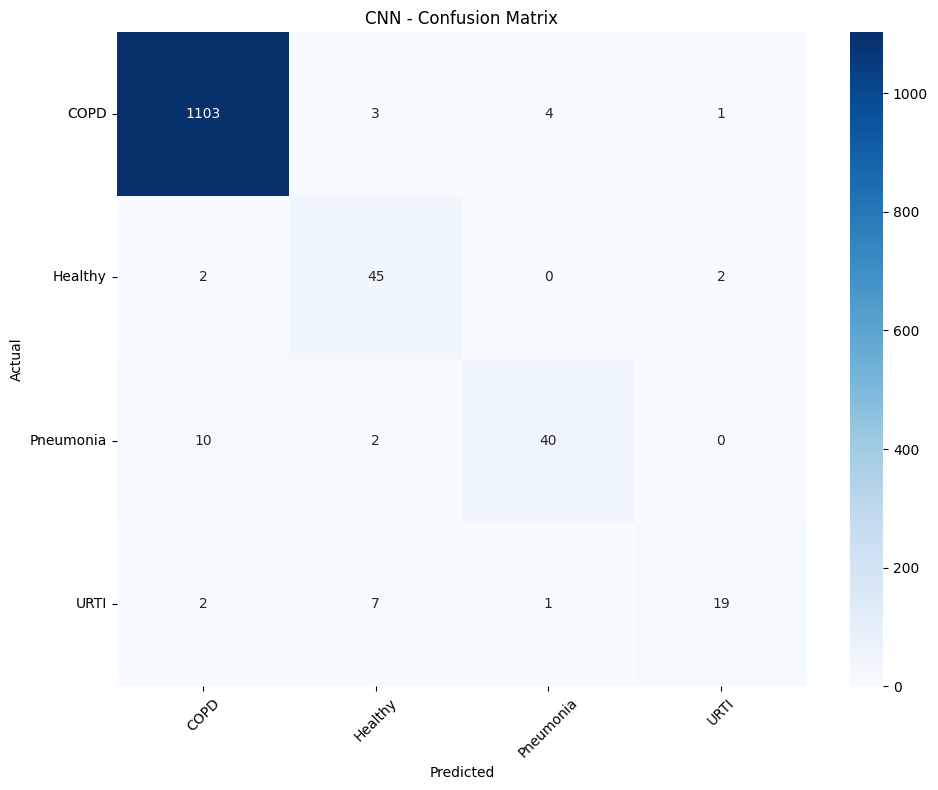

In [18]:
# Cell 17: Evaluate CNN Model
cnn_results = evaluate_model_comprehensive(
    cnn_model, 'CNN', X_test_cnn, y_test_cat, y_test, label_encoder
)



39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step

GRU Model Evaluation Results
Accuracy: 0.9508
Macro Precision: 0.7223
Macro Recall: 0.7123
Macro F1-Score: 0.6424
Weighted Precision: 0.9591
Weighted Recall: 0.9508
Weighted F1-Score: 0.9469

Per-Class Metrics:
Class           Precision  Recall     F1-Score   Support   
-----------------------------------------------------------------
COPD            0.9982     0.9784     0.9882     1111      
Healthy         0.5714     0.8980     0.6984     49        
Pneumonia       0.6528     0.9038     0.7581     52        
URTI            0.6667     0.0690     0.1250     29        

Classification Report:
              precision    recall  f1-score   support

        COPD       1.00      0.98      0.99      1111
     Healthy       0.57      0.90      0.70        49
   Pneumonia       0.65      0.90      0.76        52
        URTI       0.67      0.07      0.12        29

    accuracy                           0.95      1241
   macro avg       0.72      0.7

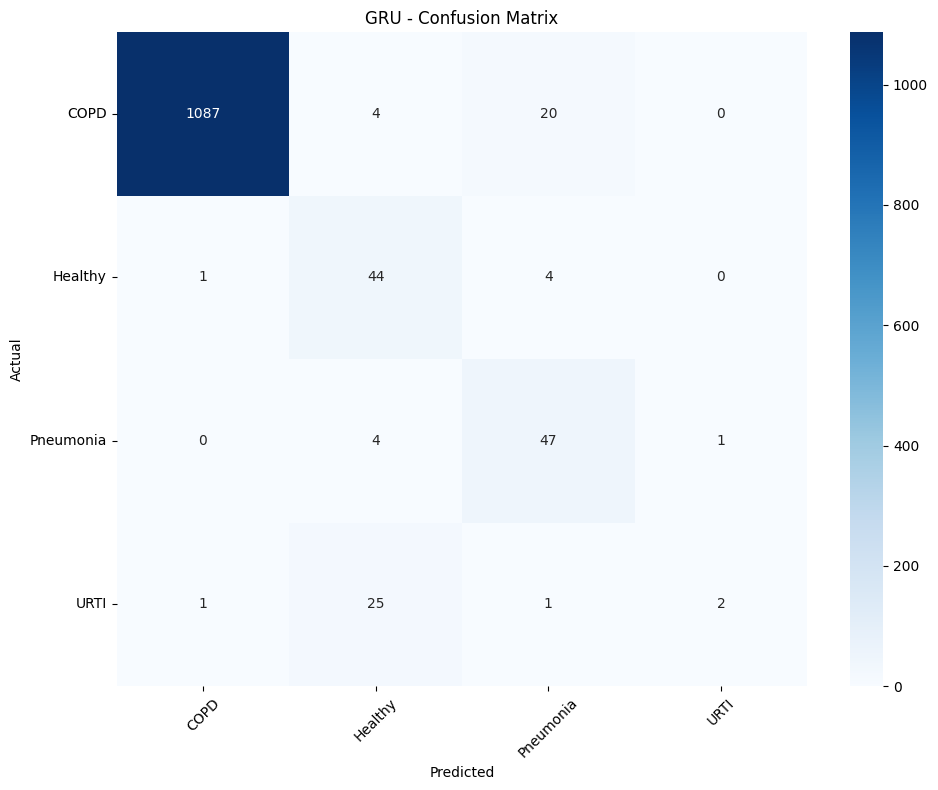

In [19]:

# Cell 18: Evaluate GRU Model
gru_results = evaluate_model_comprehensive(
    gru_model, 'GRU', X_test, y_test_cat, y_test, label_encoder
)


39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step

CNN-GRU Hybrid Model Evaluation Results
Accuracy: 0.9734
Macro Precision: 0.8742
Macro Recall: 0.7909
Macro F1-Score: 0.8046
Weighted Precision: 0.9734
Weighted Recall: 0.9734
Weighted F1-Score: 0.9706

Per-Class Metrics:
Class           Precision  Recall     F1-Score   Support   
-----------------------------------------------------------------
COPD            0.9893     0.9955     0.9924     1111      
Healthy         0.7541     0.9388     0.8364     49        
Pneumonia       0.9200     0.8846     0.9020     52        
URTI            0.8333     0.3448     0.4878     29        

Classification Report:
              precision    recall  f1-score   support

        COPD       0.99      1.00      0.99      1111
     Healthy       0.75      0.94      0.84        49
   Pneumonia       0.92      0.88      0.90        52
        URTI       0.83      0.34      0.49        29

    accuracy                           0.97      1241
   macro avg       0.

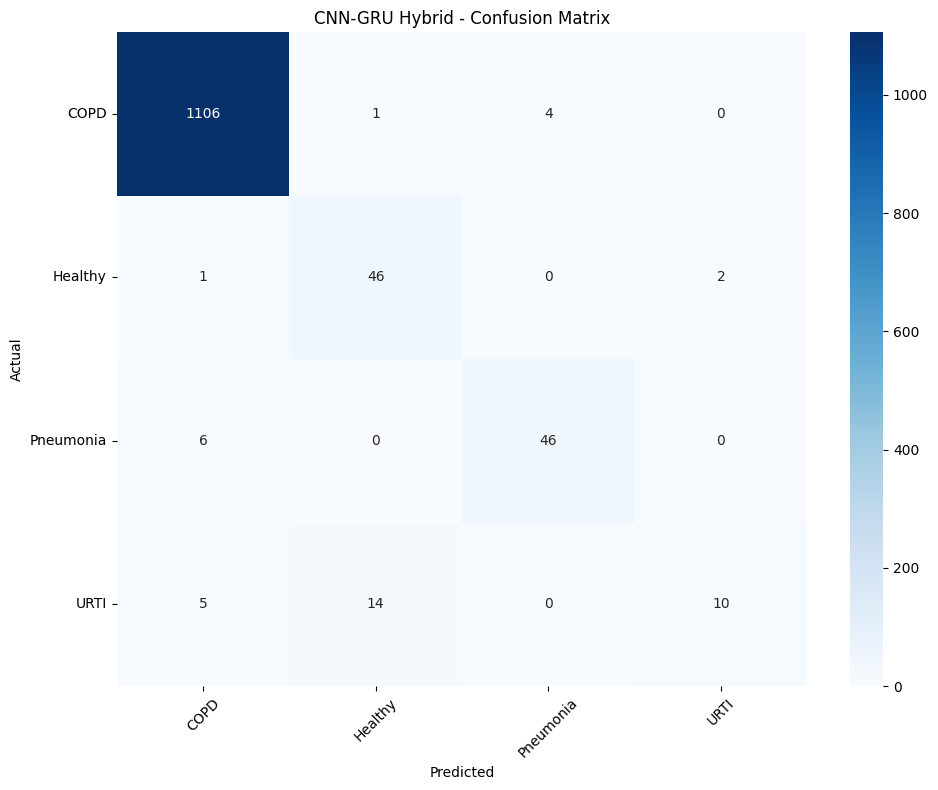

In [20]:
# Cell 19: Evaluate CNN-GRU Hybrid Model
hybrid_results = evaluate_model_comprehensive(
    hybrid_model, 'CNN-GRU Hybrid', X_test_cnn, y_test_cat, y_test, label_encoder
)


In [22]:
# Cell 20: Model Comparison Table and Best Model Selection
all_results = [cnn_results, gru_results, hybrid_results]

comparison_df = pd.DataFrame(all_results)
comparison_df = comparison_df.round(4)

print("\n" + "="*80)
print("MODEL COMPARISON TABLE")
print("="*80)
print(comparison_df.to_string(index=False))

best_model_idx = comparison_df['weighted_f1'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'model_name']
best_weighted_f1 = comparison_df.loc[best_model_idx, 'weighted_f1']

print(f"\n" + "="*50)
print("BEST MODEL IDENTIFICATION")
print("="*50)
print(f"Best Model: {best_model_name}")
print(f"Best Weighted F1-Score: {best_weighted_f1:.4f}")
print("="*50)


MODEL COMPARISON TABLE
    model_name  accuracy  macro_precision  macro_recall  macro_f1  weighted_precision  weighted_recall  weighted_f1
           CNN    0.9726           0.8824        0.8339    0.8523              0.9726           0.9726       0.9719
           GRU    0.9508           0.7223        0.7123    0.6424              0.9591           0.9508       0.9469
CNN-GRU Hybrid    0.9734           0.8742        0.7909    0.8046              0.9734           0.9734       0.9706

BEST MODEL IDENTIFICATION
Best Model: CNN
Best Weighted F1-Score: 0.9719


Plotting training curves for all models...


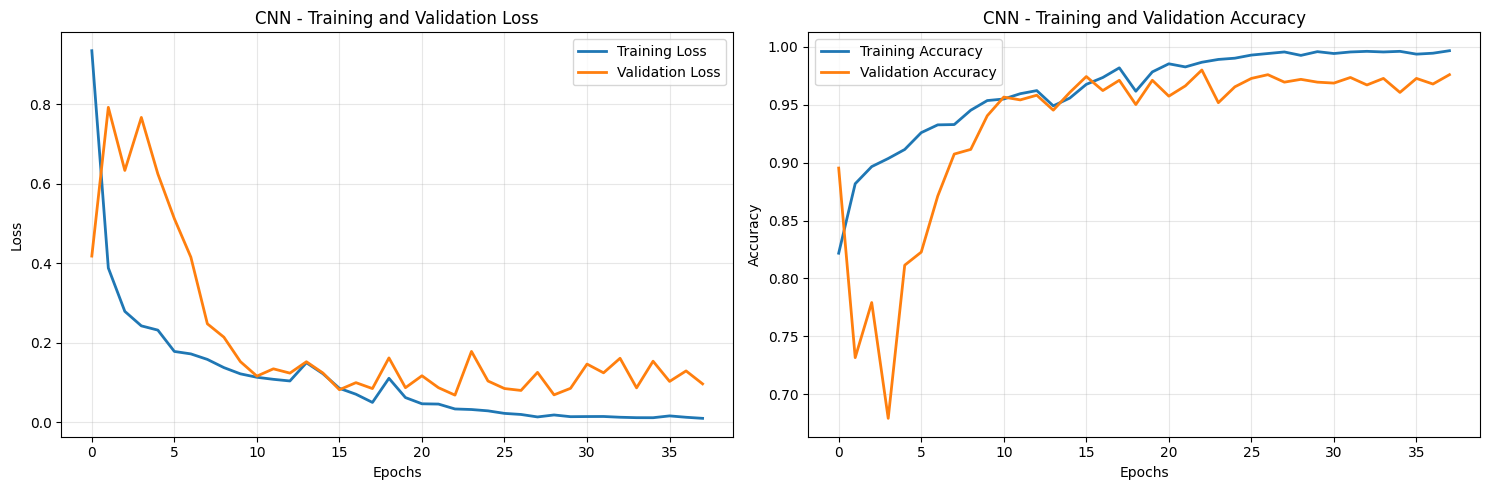

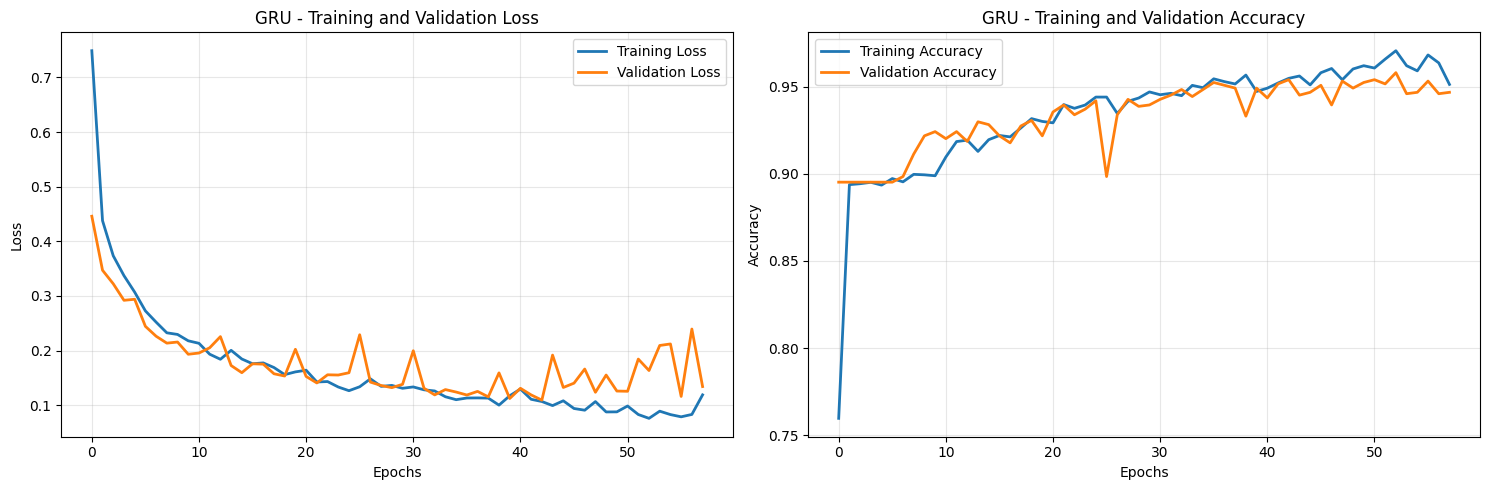

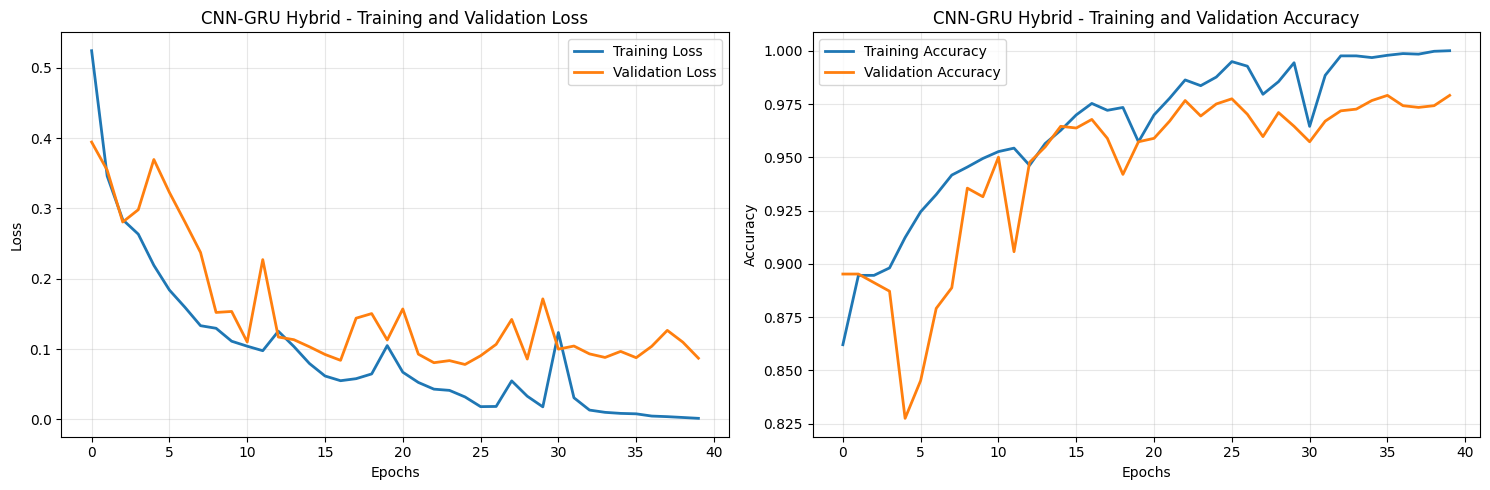

In [23]:
# Cell 21: Plot Training Curves
def plot_training_curves(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax1.set_title(f'{model_name} - Training and Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax2.set_title(f'{model_name} - Training and Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("Plotting training curves for all models...")

plot_training_curves(cnn_history, 'CNN')
plot_training_curves(gru_history, 'GRU')
plot_training_curves(hybrid_history, 'CNN-GRU Hybrid')

In [24]:

# Cell 22: Final Summary and Recommendations
print("\n" + "="*80)
print("RESPIRATORY DISEASE CLASSIFICATION - FINAL SUMMARY")
print("="*80)

print(f"Dataset Information:")
print(f"- Total viable classes: {len(viable_classes)}")
print(f"- Classes: {', '.join(viable_classes)}")
print(f"- Total samples after augmentation: {len(X)}")
print(f"- Feature dimensions: {X.shape[1]} x {X.shape[2]}")

print(f"\nModel Performance Summary:")
for result in all_results:
    print(f"- {result['model_name']}: Weighted F1 = {result['weighted_f1']:.4f}, Accuracy = {result['accuracy']:.4f}")

print(f"\nBest Performing Model: {best_model_name} (Weighted F1: {best_weighted_f1:.4f})")

print(f"\nRecommendations:")
print(f"1. The {best_model_name} model shows the best overall performance")
print(f"2. Consider ensemble methods combining multiple models for better results")
print(f"3. Experiment with different augmentation techniques for improved generalization")
print(f"4. Fine-tune hyperparameters based on validation performance")
print(f"5. Consider collecting more data for classes with lower performance")

print("\n" + "="*80)
print("NOTEBOOK EXECUTION COMPLETED SUCCESSFULLY!")
print("="*80)



RESPIRATORY DISEASE CLASSIFICATION - FINAL SUMMARY
Dataset Information:
- Total viable classes: 4
- Classes: COPD, Pneumonia, Healthy, URTI
- Total samples after augmentation: 6202
- Feature dimensions: 216 x 40

Model Performance Summary:
- CNN: Weighted F1 = 0.9719, Accuracy = 0.9726
- GRU: Weighted F1 = 0.9469, Accuracy = 0.9508
- CNN-GRU Hybrid: Weighted F1 = 0.9706, Accuracy = 0.9734

Best Performing Model: CNN (Weighted F1: 0.9719)

Recommendations:
1. The CNN model shows the best overall performance
2. Consider ensemble methods combining multiple models for better results
3. Experiment with different augmentation techniques for improved generalization
4. Fine-tune hyperparameters based on validation performance
5. Consider collecting more data for classes with lower performance

NOTEBOOK EXECUTION COMPLETED SUCCESSFULLY!
